## Architecture #3 + OG Neutrosophic Loss (Low Data Regime)

##### 1. Imports

In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.layers import ( 
    SpatialDropout1D, Embedding, Bidirectional, 
    LSTM, Dense, Dropout, 
    BatchNormalization, Input, Layer,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate,
    Attention, MultiHeadAttention, LayerNormalization
)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

2026-02-06 09:21:06.890922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770369667.064406      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770369667.116089      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.keras.utils.set_random_seed(42)

##### 2. Load Dataset (20%)

In [3]:
file = r"/kaggle/input/bias-detection-dataset-processed/balanced_bias_data_parquet.parquet"
balanced_df = pd.read_parquet(file)
balanced_df = balanced_df.sample(frac=0.6, random_state=42).reset_index(drop=True)

print(balanced_df)
print("\nColumns:", balanced_df.columns)
print("\nShape:", balanced_df.shape)

         Unnamed: 0                                               text  \
0            907743  i cant breathe! just call me hott stuffy! lol....   
1           1758411  the cma is dominated by social justice warrior...   
2           2316667  one thing trump has done for the better is to ...   
3           1276711  the compensation for the 11 deaths in his fami...   
4           2242836  so to summarizennmischaracterization lie lie l...   
...             ...                                                ...   
1714077     1192065  give it a rest. boo hoo, people against aca ar...   
1714078      178765  hello and thanks for the info,nni just did the...   
1714079     1142793  precisely richard. if youre in toronto i urge ...   
1714080      811698      illegal immigration is worse than pedophilia?   
1714081     1943668  exactly! progressives should be very happy wit...   

                                              biased_words  bias  sentiment  \
0                               

##### 3. Tokenisation & Padding

In [4]:
MAX_VOCAB = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(balanced_df['text'])

X = tokenizer.texts_to_sequences(balanced_df['text'])
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')
print(X.shape)

(1714082, 100)


##### 4. Train-Test Split

In [5]:
y = balanced_df[['bias', 'sentiment', 'toxic']]
print(y)
print(y.shape)

         bias  sentiment  toxic
0           1          2      1
1           2          2      0
2           0          2      1
3           0          0      0
4           2          1      1
...       ...        ...    ...
1714077     2          0      1
1714078     1          2      0
1714079     2          0      1
1714080     0          0      1
1714081     2          2      1

[1714082 rows x 3 columns]
(1714082, 3)


In [6]:
# split for training, testing and validation as 80%-10%-10%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_valid:", X_valid.shape)

y_train_bias = y_train["bias"].to_numpy()
y_train_sentiment = y_train["sentiment"].to_numpy()
y_train_toxic = y_train["toxic"].to_numpy()

print("y_train_bias:", y_train_bias.shape)
print("y_train_sentiment:", y_train_sentiment.shape)
print("y_train_toxic:", y_train_toxic.shape)

y_test_bias = y_test["bias"].to_numpy()
y_test_sentiment = y_test["sentiment"].to_numpy()
y_test_toxic = y_test["toxic"].to_numpy()

print("y_test_bias:", y_test_bias.shape)
print("y_test_sentiment:", y_test_sentiment.shape)
print("y_test_toxic:", y_test_toxic.shape)

y_valid_bias = y_valid["bias"].to_numpy()
y_valid_sentiment = y_valid["sentiment"].to_numpy()
y_valid_toxic = y_valid["toxic"].to_numpy()

print("y_valid_bias:", y_valid_bias.shape)
print("y_valid_sentiment:", y_valid_sentiment.shape)
print("y_valid_toxic:", y_valid_toxic.shape)

X_train: (1199857, 100)
X_test: (257112, 100)
X_valid: (257113, 100)
y_train_bias: (1199857,)
y_train_sentiment: (1199857,)
y_train_toxic: (1199857,)
y_test_bias: (257112,)
y_test_sentiment: (257112,)
y_test_toxic: (257112,)
y_valid_bias: (257113,)
y_valid_sentiment: (257113,)
y_valid_toxic: (257113,)


In [8]:
y_train_bias_oh = to_categorical(y_train_bias, num_classes=3)
y_valid_bias_oh = to_categorical(y_valid_bias, num_classes=3)
y_test_bias_oh = to_categorical(y_test_bias, num_classes=3)

y_train_sentiment_oh = to_categorical(y_train_sentiment, num_classes=3)
y_valid_sentiment_oh = to_categorical(y_valid_sentiment, num_classes=3)
y_test_sentiment_oh = to_categorical(y_test_sentiment, num_classes=3)

y_train_toxic_oh = to_categorical(y_train_toxic, num_classes=2)
y_valid_toxic_oh = to_categorical(y_valid_toxic, num_classes=2)
y_test_toxic_oh = to_categorical(y_test_toxic, num_classes=2)

##### 5. Neutrosophic Loss Function

In [9]:
def neutrosophic_loss(alpha, beta, gamma):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_sigmoid = tf.clip_by_value(tf.nn.sigmoid(y_pred), 1e-7, 1-1e-7)

        truth = -y_true * tf.math.log(y_sigmoid)
        falsity = -(1 - y_true) * tf.math.log(1 - y_sigmoid)
        indeterminacy = 1.0 - tf.abs(y_sigmoid - 0.5) * 2.0

        neutro_loss = alpha * truth + beta * falsity + gamma * indeterminacy
        return tf.reduce_mean(neutro_loss)
    return loss_fn

##### 6. Model Architecture

In [10]:
def build_model(alpha, beta, gamma):
    MAX_VOCAB = 10000
    input_layer = Input(shape=(100,))
    
    x = Embedding(MAX_VOCAB, 512, trainable=True)(input_layer)
    
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3))(x)
    x = LayerNormalization()(x)
    
    # Multi-head attention
    attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    
    # Dual pooling
    avg_pool = GlobalAveragePooling1D()(attn)
    max_pool = GlobalMaxPooling1D()(attn)
    x = Concatenate()([avg_pool, max_pool])
    
    x = Dense(256, activation="gelu")(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation="gelu", kernel_regularizer=l2(1e-4))(x)

    neutro = Dense(128, activation="tanh", name="neutro_latent")(x)
    
    # Output heads
    output_b = Dense(3, activation='linear', name='output_b')(neutro)
    output_s = Dense(3, activation='linear', name='output_s')(neutro)
    output_t = Dense(2, activation='linear', name='output_t')(neutro)
    
    model = Model(inputs=input_layer, outputs=[output_b, output_s, output_t])

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=10000,
        decay_rate=0.9
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss={
            "output_b": neutrosophic_loss(alpha, beta, gamma),
            "output_s": neutrosophic_loss(alpha, beta, gamma),
            "output_t": neutrosophic_loss(alpha, beta, gamma),
        },
        metrics={
            "output_b": tf.keras.metrics.CategoricalAccuracy(name="acc"),
            "output_s": tf.keras.metrics.CategoricalAccuracy(name="acc"),
            "output_t": tf.keras.metrics.CategoricalAccuracy(name="acc")
        }
    )
    return model

##### 6. Model Training

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model = build_model(0.9391, 0.6620, 0.1349)

history = model.fit(
    X_train,
    {
        "output_b": y_train_bias_oh,
        "output_s": y_train_sentiment_oh,
        "output_t": y_train_toxic_oh
    },
    validation_data=(
        X_valid,
        {
            "output_b": y_valid_bias_oh,
            "output_s": y_valid_sentiment_oh,
            "output_t": y_valid_toxic_oh
        }
    ),
    epochs=10,
    batch_size=512,
    verbose=1,
    callbacks=[early_stopping]
)

I0000 00:00:1770369775.297734      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1770369790.366692     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


2344/2344 ━━━━━━━━━━━━━━━━━━━━ 406s 167ms/step - loss: 1.0531 - output_b_acc: 0.7554 - output_b_loss: 0.3202 - output_s_acc: 0.7696 - output_s_loss: 0.3101 - output_t_acc: 0.7713 - output_t_loss: 0.4113 - val_loss: 0.6861 - val_output_b_acc: 0.8560 - val_output_b_loss: 0.2114 - val_output_s_acc: 0.9048 - val_output_s_loss: 0.1589 - val_output_t_acc: 0.8429 - val_output_t_loss: 0.3109
Epoch 2/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 390s 166ms/step - loss: 0.6779 - output_b_acc: 0.8564 - output_b_loss: 0.2115 - output_s_acc: 0.9051 - output_s_loss: 0.1588 - output_t_acc: 0.8470 - output_t_loss: 0.3033 - val_loss: 0.6484 - val_output_b_acc: 0.8644 - val_output_b_loss: 0.2004 - val_output_s_acc: 0.9132 - val_output_s_loss: 0.1465 - val_output_t_acc: 0.8507 - val_output_t_loss: 0.2983
Epoch 3/10
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 390s 166ms/step - loss: 0.6289 - output_b_acc: 0.8681 - output_b_loss: 0.1967 - output_s_acc: 0.9143 - output_s_loss: 0.1455 - output_t_acc: 0.8581 - output_t_loss: 0.2835 -

##### 7. Model Evaluation

2009/2009 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step
====================== Bias Task ======================
Accuracy: 0.8861
                 precision    recall  f1-score   support

  Highly Biased       0.91      0.92      0.92     73700
        Neutral       0.88      0.90      0.89     80185
Slightly Biased       0.87      0.86      0.86    103227

       accuracy                           0.89    257112
      macro avg       0.89      0.89      0.89    257112
   weighted avg       0.89      0.89      0.89    257112


==================== Sentiment Task ====================
Accuracy: 0.9269
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90     56656
     Neutral       0.93      0.92      0.93     88501
    Positive       0.94      0.95      0.94    111955

    accuracy                           0.93    257112
   macro avg       0.92      0.92      0.92    257112
weighted avg       0.93      0.93      0.93    257112


====================== 

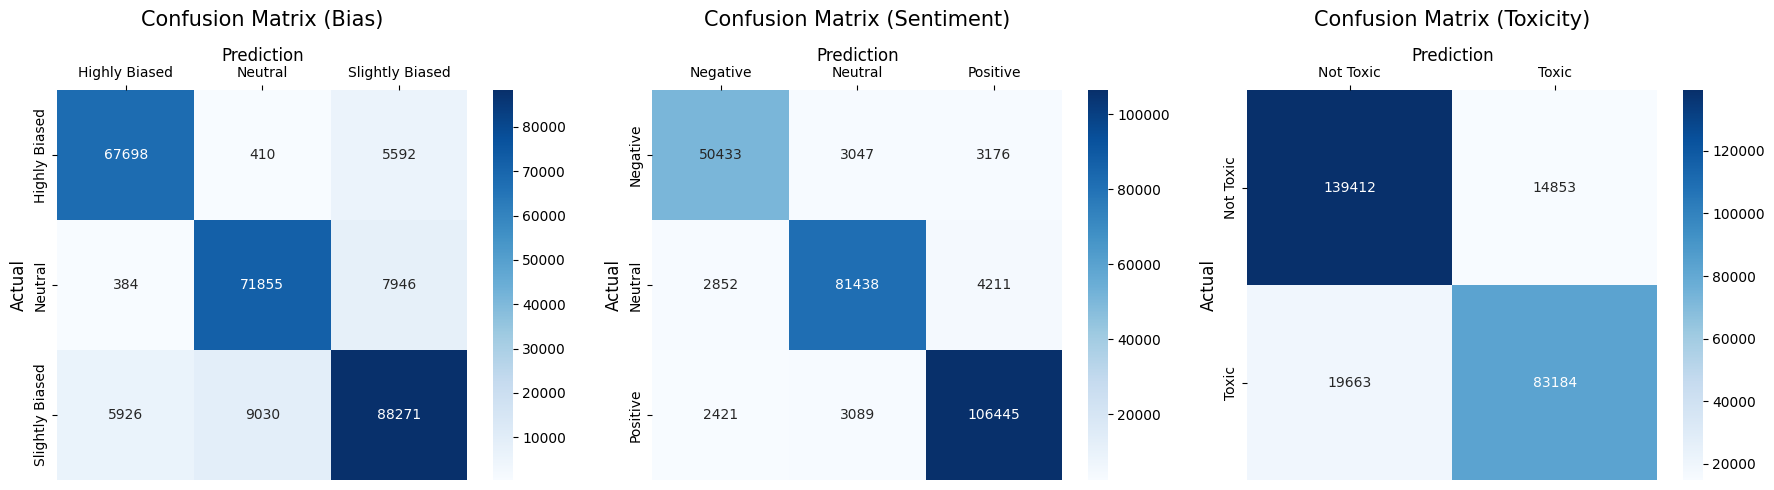

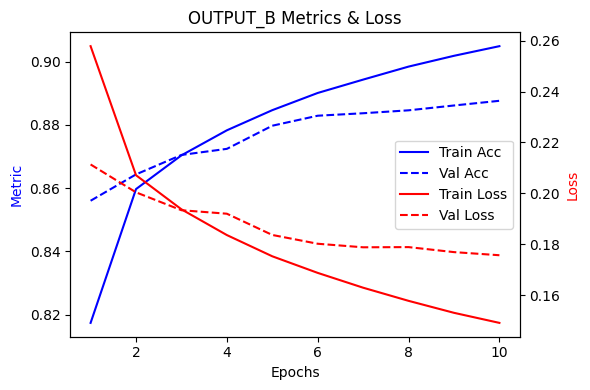

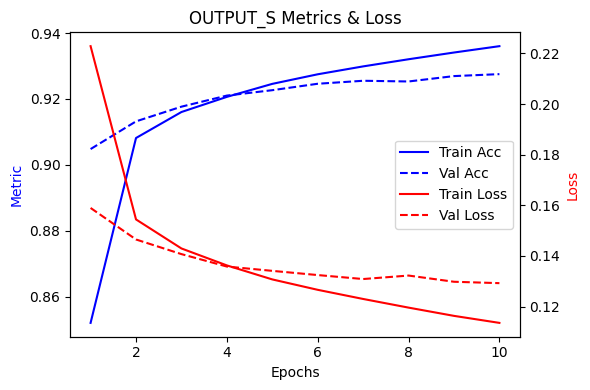

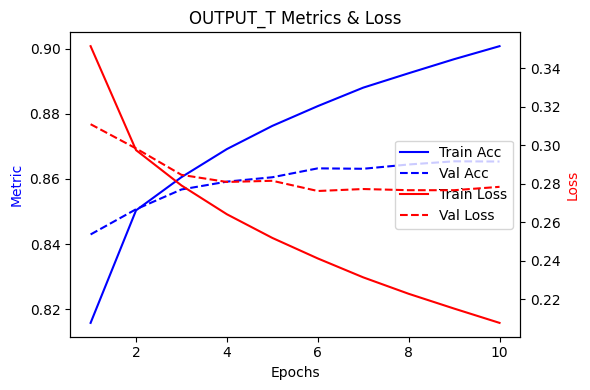


--------------------------------------------------------------------------



In [12]:
y_pred_probs = model.predict(X_test, batch_size=128)

y_pred_bias = np.argmax(y_pred_probs[0], axis=1)
y_pred_sentiment = np.argmax(y_pred_probs[1], axis=1)
y_pred_toxic = np.argmax(y_pred_probs[2], axis=1)

y_true_bias = np.argmax(y_test_bias_oh, axis=1)
y_true_sentiment = np.argmax(y_test_sentiment_oh, axis=1)
y_true_toxic = np.argmax(y_test_toxic_oh, axis=1)

bias_labels = ['Highly Biased', 'Neutral', 'Slightly Biased']
sentiment_labels = ['Negative', 'Neutral', 'Positive']
toxicity_labels = ['Not Toxic', 'Toxic']

print("====================== Bias Task ======================")
print(f"Accuracy: {accuracy_score(y_true_bias, y_pred_bias):.4f}")
print(classification_report(y_true_bias, y_pred_bias, target_names=bias_labels))

print("\n==================== Sentiment Task ====================")
print(f"Accuracy: {accuracy_score(y_true_sentiment, y_pred_sentiment):.4f}")
print(classification_report(y_true_sentiment, y_pred_sentiment, target_names=sentiment_labels))

print("\n====================== Toxic Task ======================")
print(f"Accuracy: {accuracy_score(y_true_toxic, y_pred_toxic):.4f}")
print(classification_report(y_true_toxic, y_pred_toxic, target_names=toxicity_labels))

def plot_cm(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
    ax.set_title(title, fontsize=15, pad=15)
    ax.set_xlabel('Prediction', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(y_true_bias, y_pred_bias, bias_labels, 'Confusion Matrix (Bias)', axes[0])
plot_cm(y_true_sentiment, y_pred_sentiment, sentiment_labels, 'Confusion Matrix (Sentiment)', axes[1])
plot_cm(y_true_toxic, y_pred_toxic, toxicity_labels, 'Confusion Matrix (Toxicity)', axes[2])

plt.tight_layout()
plt.show()

def plot_history_combined(history, outputs, metrics=None):
    if metrics is None:
        metrics = []
        for key in history.history.keys():
            for output in outputs:
                if key.startswith(output) and not key.endswith("loss"):
                    metric_name = key[len(output)+1:]  # remove output_
                    if metric_name not in metrics:
                        metrics.append(metric_name)
    
    epochs = range(1, len(history.history[f"{outputs[0]}_loss"]) + 1)

    for output in outputs:
        fig, ax1 = plt.subplots(figsize=(6, 4))

        ax2 = ax1.twinx()
        for metric in metrics:
            train_metric = history.history.get(f"{output}_{metric}")
            val_metric = history.history.get(f"val_{output}_{metric}")
            if train_metric and val_metric:
                ax1.plot(epochs, train_metric, "b-", label=f"Train {metric.title()}")
                ax1.plot(epochs, val_metric, "b--", label=f"Val {metric.title()}")

        train_loss = history.history.get(f"{output}_loss")
        val_loss = history.history.get(f"val_{output}_loss")
        if train_loss and val_loss:
            ax2.plot(epochs, train_loss, "r-", label="Train Loss")
            ax2.plot(epochs, val_loss, "r--", label="Val Loss")

        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Metric", color="b")
        ax2.set_ylabel("Loss", color="r")
        ax1.set_title(f"{output.upper()} Metrics & Loss")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

        plt.tight_layout()
        plt.show()
    
outputs = ["output_b", "output_s", "output_t"]
plot_history_combined(history, outputs)

print("\n--------------------------------------------------------------------------\n")